In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"../../../../output/age_depth_unified_cap/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_unified_cap/energy_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_unified_cap/bias_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/age_depth_unified_cap/resamp_{config_str}.npy")

In [4]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(4, 99900, 10)
(4, 100000, 10)


In [5]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [6]:
print(energy_values)

[[47.06549015 45.3762078  44.30678039 ... 31.77507203 32.02366794
  33.10649042]
 [49.94756584 46.02951408 38.63574912 ... 30.79709294 31.65727279
  28.56776408]
 [47.09720477 45.46920773 41.4532509  ... 48.28717618 47.63066747
  47.89856752]
 [48.55679947 45.50662982 41.27852839 ... 31.13441494 35.30311611
  31.807536  ]]


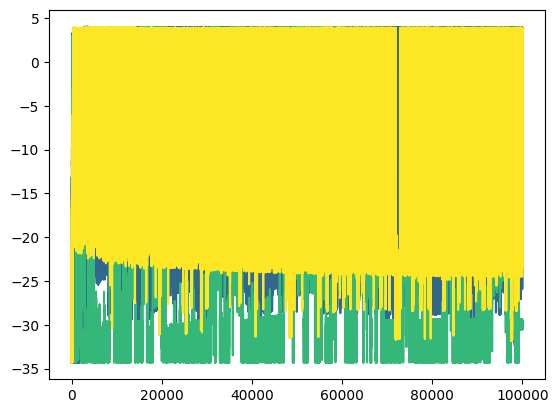

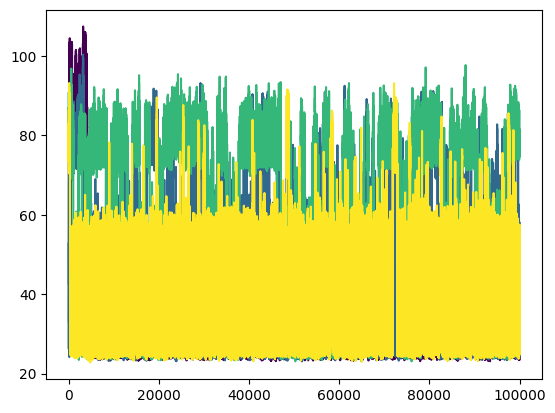

In [7]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()


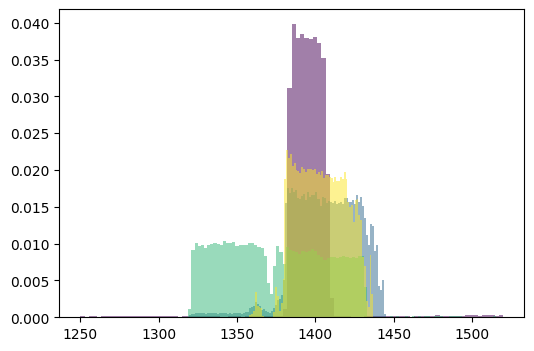

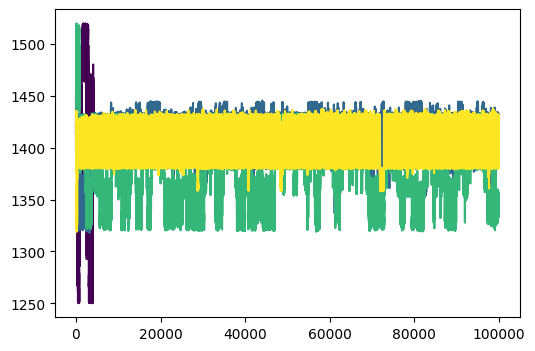

In [8]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

In [9]:
resampled_samples = resampled_samples[:,::1000,:]

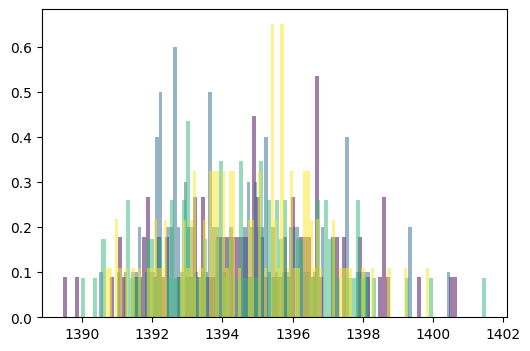

In [10]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

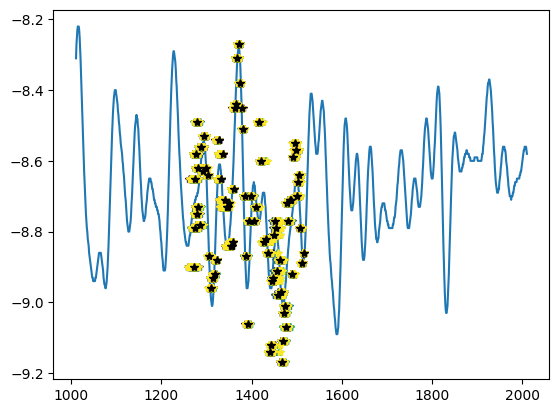

In [11]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [12]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]  10.13  1.08    8.14    12.20       0.05     0.04    419.43    374.27   
x[1]  11.23  1.79    7.86    14.52       0.09     0.06    404.52    416.87   
x[2]   8.09  2.37    3.33    12.17       0.12     0.08    405.92    416.07   
x[3]  10.30  2.48    5.27    14.17       0.12     0.12    416.33    370.90   
x[4]  22.93  1.84   19.75    25.37       0.10     0.15    358.20    373.46   
x[5]  13.57  1.74   10.56    16.98       0.09     0.06    405.49    415.80   
x[6]  13.40  2.31    8.95    17.55       0.11     0.09    475.06    335.46   
x[7]  14.40  2.45    9.70    18.85       0.12     0.10    439.75    308.40   
x[8]  14.80  2.24   11.07    19.07       0.11     0.09    416.79    294.72   
x[9]   5.93  3.63    0.68    12.83       0.18     0.13    410.74    416.33   

      r_hat  
x[0]   1.02  
x[1]   1.00  
x[2]   1.00  
x[3]   1.01  
x[4]   1.00  
x[5]   1.01  
x[6]   1.01  
x[7]   1.01  
x[8]   1.00  
x

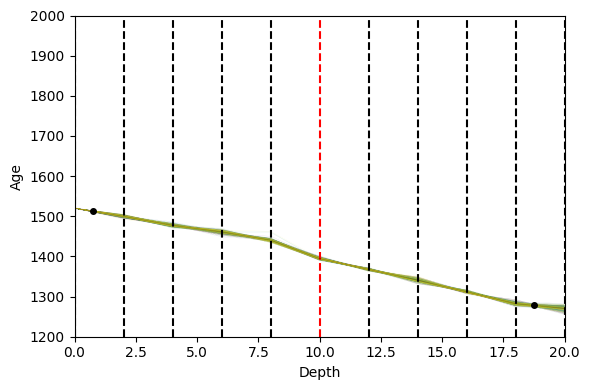

In [13]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()